## Load

In [ ]:
%pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
dataset_path = "/".join((path, "heart_disease_uci.csv"))

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [ ]:
df = pd.read_csv(dataset_path)
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Data Exploration

### describe

In [ ]:
import numpy as np
print(df.info())
display(df.select_dtypes(include=[np.number]).describe())
display(df.select_dtypes(exclude=[np.number]).describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


### isna

In [ ]:
print("Nan values:")
display(df.isna().sum().sort_values(ascending=False))


Nan values:


,0
ca,611
thal,486
slope,309
fbs,90
oldpeak,62
trestbps,59
exang,55
thalch,55
chol,30
restecg,2


### isna by dataset / num

In [ ]:
display(df.groupby('dataset').apply(lambda x: x.isna().sum()))
display(df.groupby('num').apply(lambda x: x.isna().sum()))

/tmp/ipython-input-294669755.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df.groupby('dataset').apply(lambda x: x.isna().sum()))


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
dataset,,,,,,,,,,,,,,,,
Cleveland,0,0,0,0,0,0,0,0,0,0,0,0,1,5,3,0
Hungary,0,0,0,0,0,1,23,8,1,1,1,0,189,290,265,0
Switzerland,0,0,0,0,0,2,0,75,1,1,1,6,17,118,52,0
VA Long Beach,0,0,0,0,0,56,7,7,0,53,53,56,102,198,166,0


/tmp/ipython-input-294669755.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df.groupby('num').apply(lambda x: x.isna().sum()))


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
num,,,,,,,,,,,,,,,,
0,0,0,0,0,0,20,19,14,0,20,20,21,193,246,224,0
1,0,0,0,0,0,39,11,76,2,35,35,41,116,365,262,0


Nu este nicio corelare intre faptul ca un om e sanatos si faptul ca nu a facut testele. Testele nu s-au facut in functie de locatie, deci nu putem prezice valori. Deci randurile care au multe valori lipsa sunt pot produce bias nejustificat, deci va trbui facut drop pe ele.

### Distribution Histograms

id: max=920, unique=920, bins=30, discrete=False


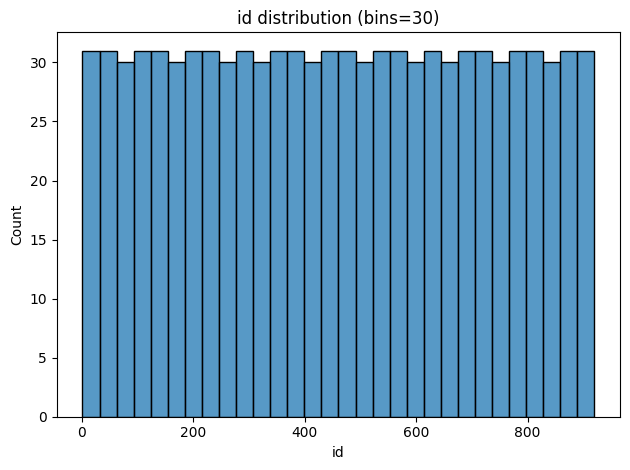

age: max=77, unique=50, bins=30, discrete=False


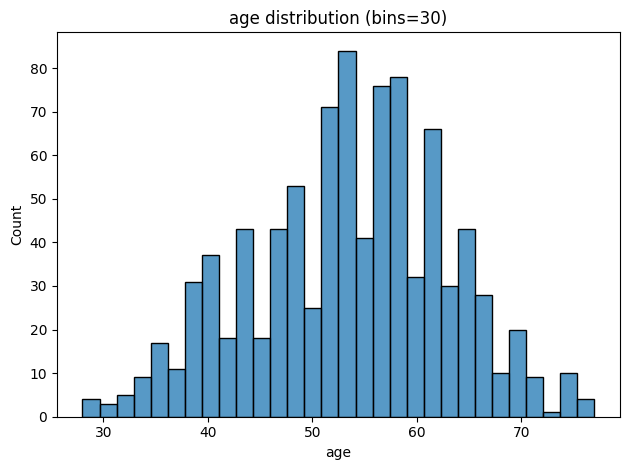

trestbps: max=200.0, unique=61, bins=29, discrete=False


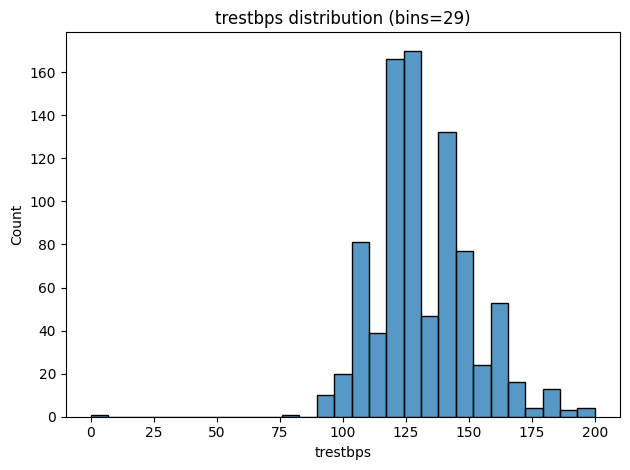

chol: max=603.0, unique=217, bins=29, discrete=False


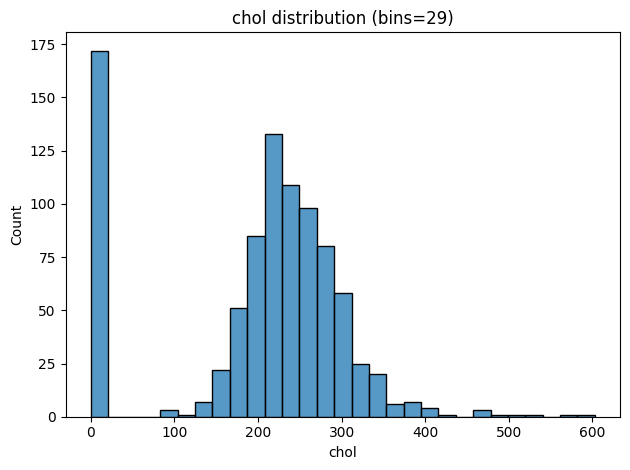

thalch: max=202.0, unique=119, bins=29, discrete=False


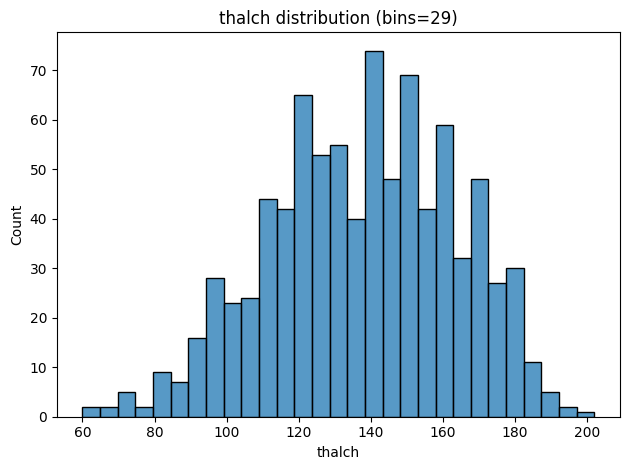

oldpeak: max=6.2, unique=53, bins=29, discrete=False


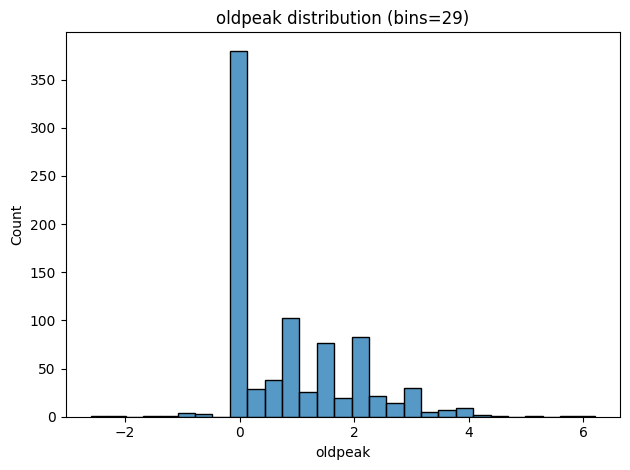

ca: max=3.0, unique=4, bins=17, discrete=False


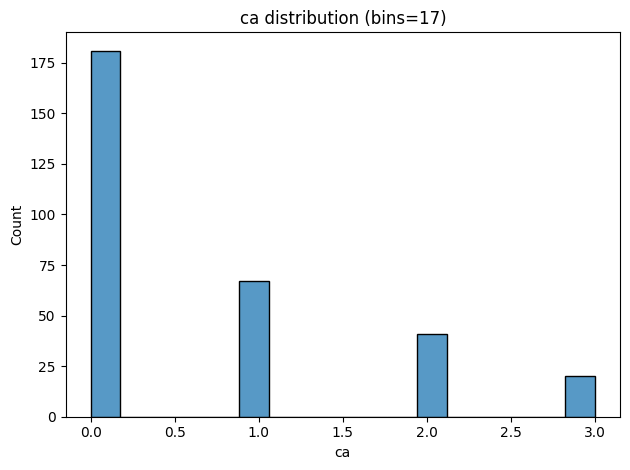

num: max=1, unique=2, bins=2, discrete=True


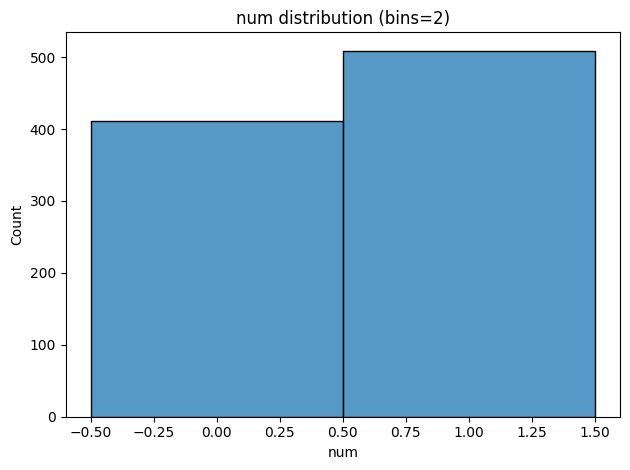

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
  cleaned = df[c].dropna()
  max_val = cleaned.max()
  n = len(cleaned)
  # Decide bins:
  # If data look like small-range integers (few unique values) use that count (discrete histogram)
  n_unique = cleaned.nunique()
  use_discrete = False
  if pd.api.types.is_integer_dtype(cleaned) and 1 < n_unique <= 20:
      bins = n_unique
      use_discrete = True
  else:
      # Fallback: Freedman–Diaconis inspired simple heuristic (sqrt fallback) capped
      # sqrt(n) is a simple rule-of-thumb; keep within [10, 40]
      bins = int(np.sqrt(n)) if n > 0 else 1
      bins = max(10, min(40, bins))
  print(f'{c}: max={max_val}, unique={n_unique}, bins={bins}, discrete={use_discrete}')
  sns.histplot(cleaned, bins=bins, discrete=use_discrete)
  plt.title(f'{c} distribution (bins={bins})')
  plt.tight_layout()
  plt.show()

### Categorical features distribution

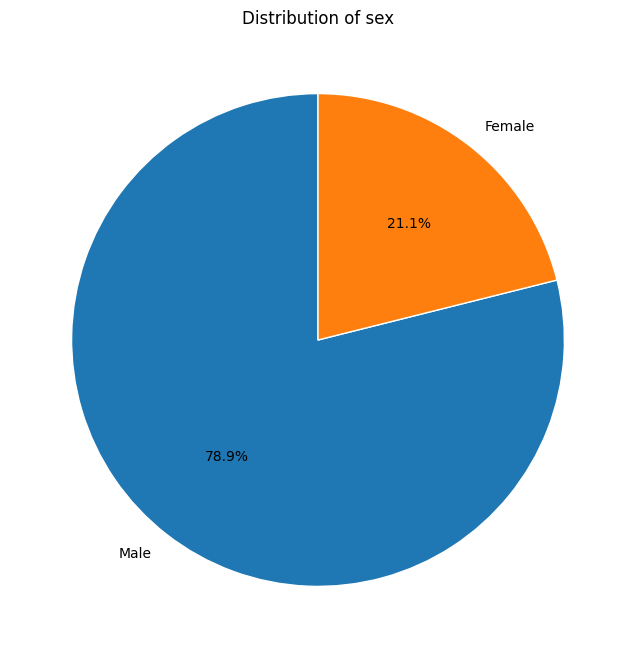

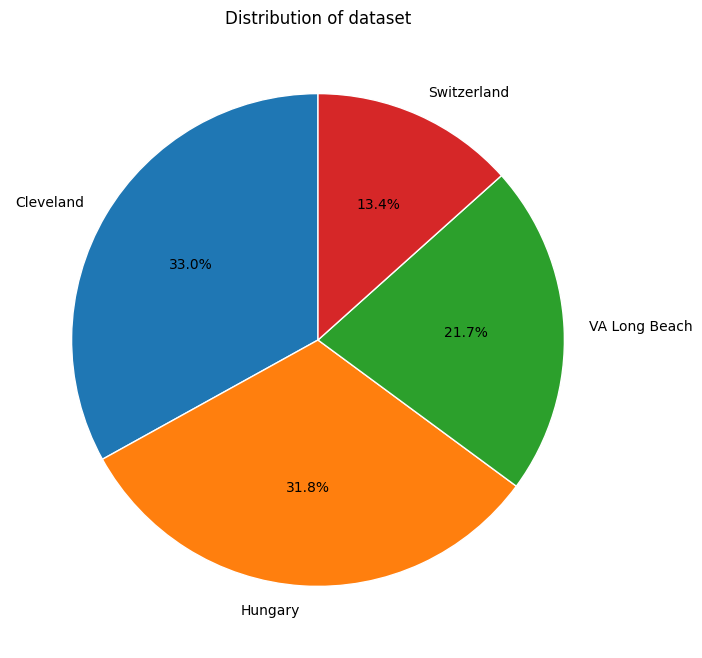

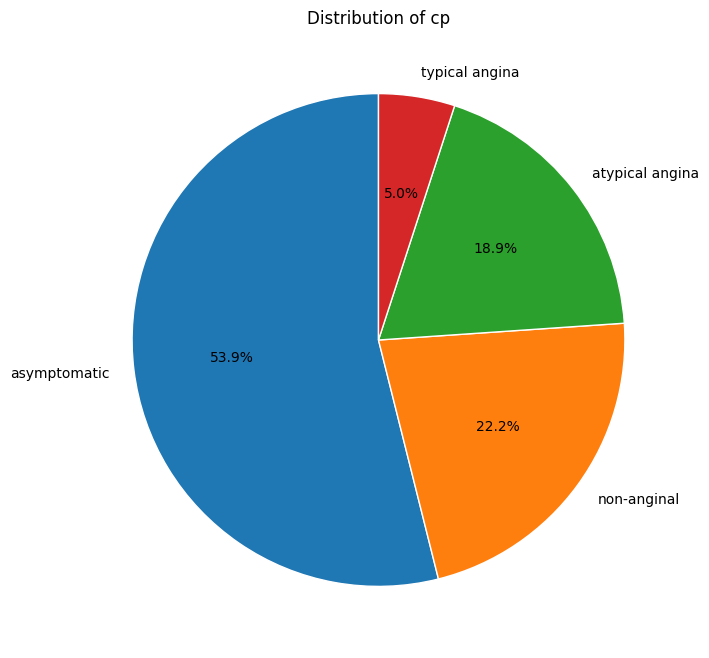

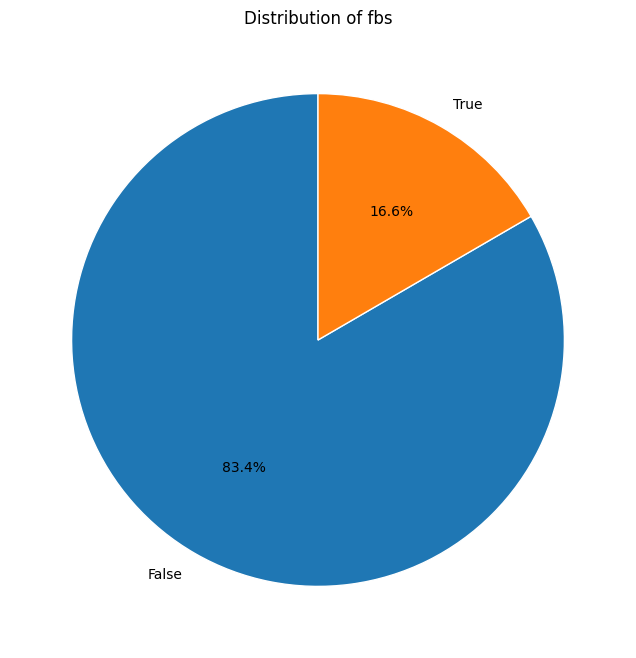

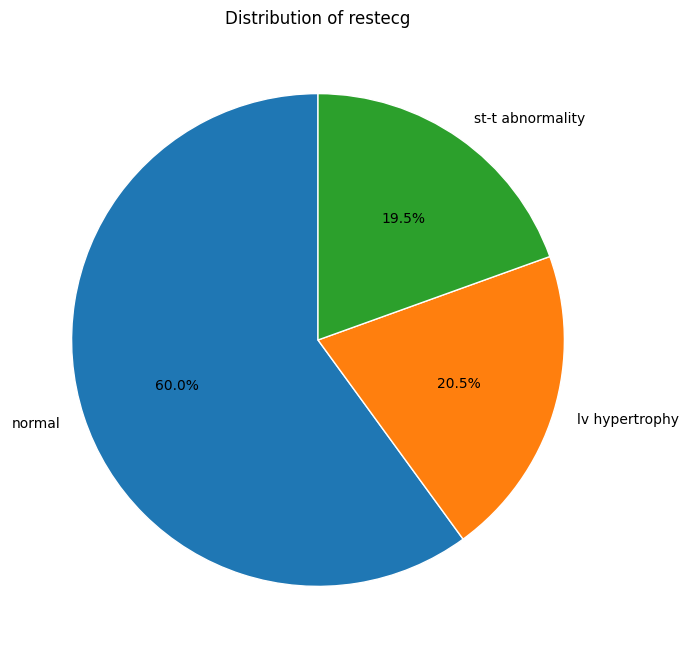

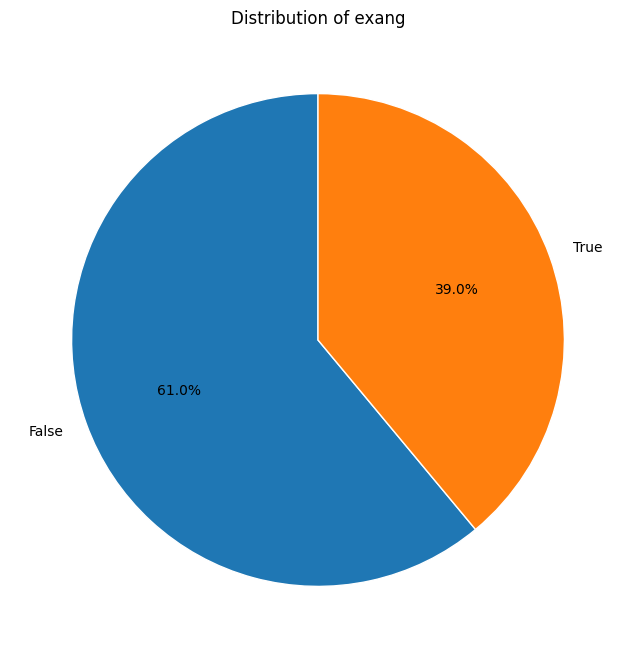

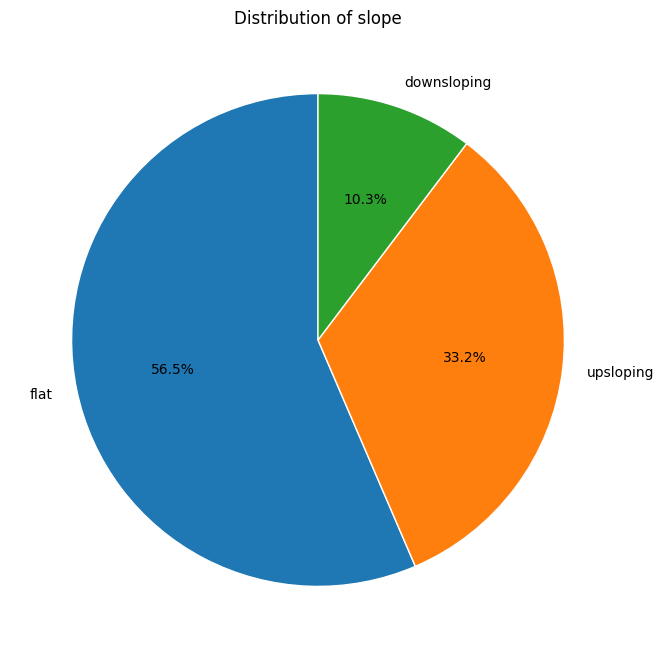

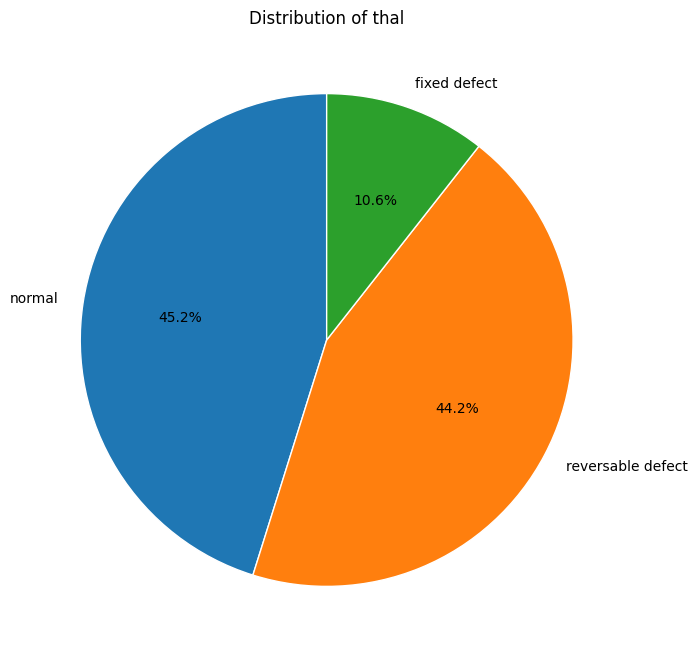

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(8, 8))
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
    plt.title(f'Distribution of {col}')
    plt.ylabel('') # Remove default y-label
    plt.show()

### Transform chol = 0 into nan

In [ ]:
df.loc[df['chol'] == 0, 'chol'] = np.nan

Transform sex into 0/1

In [ ]:
df['sex'] = df['sex'].map({'Female': 0, 'Male': 1})
print("Transformed 'sex' column:")
display(df['sex'].head())

Transformed 'sex' column:


,sex
0,1
1,1
2,1
3,1
4,0


### 'ca' corr to 'num'

In [ ]:
ca_num_counts = df.groupby('ca')['num'].value_counts(normalize=True).unstack(fill_value=0)

if 0 in ca_num_counts.columns:
    ca_num_counts['percent_num_0'] = ca_num_counts[0] * 100
    print("Percentage of num=0 for each unique 'ca' value:")
    display(ca_num_counts['percent_num_0'])
else:
    print("No instances where num is 0 in the 'ca' column.")

Percentage of num=0 for each unique 'ca' value:


,percent_num_0
ca,
0.0,73.480663
1.0,31.343284
2.0,19.512195
3.0,15.000000


Nu putem face drop la 'ca' pt ca e corelata cu sanatatea pacientului.

### isna features corr to 'num'

In [ ]:
import pandas as pd
import numpy as np

numerical_features = ['ca', 'chol']
print("Numerical Features")
for col in numerical_features:
    if col in df.columns and 'num' in df.columns:
        temp_df = df[[col, 'num']].dropna()
        if not temp_df.empty:
            correlation = temp_df[col].corr(temp_df['num'])
            print(f"Correlation between '{col}' and 'num': {correlation:.4f}")

categorical_features = ['thal', 'slope', 'fbs']
print("\nCategorical Features")
for col in categorical_features:
    if col in df.columns and 'num' in df.columns:
        print(f"\nDistribution for '{col}':")
        display(df.groupby(col)['num'].value_counts(normalize=True).unstack(fill_value=0))
    else:
        print(f"Cannot show distribution for '{col}' and 'num' as columns are missing.")

Numerical Features
Correlation between 'ca' and 'num': 0.4556
Correlation between 'chol' and 'num': 0.1183

Categorical Features

Distribution for 'thal':


num,0,1
thal,,
fixed defect,0.239130,0.760870
normal,0.704082,0.295918
reversable defect,0.197917,0.802083



Distribution for 'slope':


num,0,1
slope,,
downsloping,0.222222,0.777778
flat,0.228986,0.771014
upsloping,0.615764,0.384236



Distribution for 'fbs':


num,0,1
fbs,,
False,0.510116,0.489884
True,0.318841,0.681159


### other

In [ ]:
import numpy as np

missing_cols = df.columns[df.isna().sum() > 0].tolist()

categorical_missing_cols = [col for col in missing_cols if col in df.select_dtypes(include='object').columns]
numerical_missing_cols = [col for col in missing_cols if col in df.select_dtypes(include=np.number).columns]
print(df['thal'].unique())
print("Categorical columns with missing values:", categorical_missing_cols)
print("Numerical columns with missing values:", numerical_missing_cols)

['fixed defect' 'normal' 'reversable defect' nan]
Categorical columns with missing values: ['fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical columns with missing values: ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


In [ ]:
print(df['trestbps'].sort_values().head(10).values)
print(df['chol'].sort_values().head(180).values)
no_nans = df['chol'].dropna()
print(no_nans.sort_values().tail(40).values)
print(df['dataset'].unique())


[ 0. 80. 92. 94. 94. 95. 95. 95. 95. 95.]
[ 85. 100. 100. 117. 126. 129. 131. 132. 139. 141. 142. 147. 147. 149.
 149. 153. 156. 157. 160. 160. 160. 160. 160. 161. 161. 163. 163. 164.
 164. 165. 166. 166. 166. 167. 167. 168. 168. 169. 170. 170. 171. 171.
 171. 172. 172. 173. 173. 174. 175. 175. 175. 175. 176. 177. 177. 177.
 177. 177. 178. 179. 179. 180. 180. 180. 181. 182. 182. 182. 182. 182.
 183. 184. 184. 184. 184. 185. 186. 186. 186. 186. 186. 186. 187. 187.
 188. 188. 188. 188. 190. 192. 192. 192. 193. 193. 193. 193. 193. 193.
 194. 194. 195. 195. 195. 195. 195. 195. 196. 196. 196. 196. 196. 196.
 197. 197. 197. 197. 197. 197. 197. 198. 198. 198. 198. 198. 198. 199.
 199. 199. 200. 200. 200. 200. 201. 201. 201. 201. 201. 201. 202. 202.
 202. 203. 203. 203. 203. 203. 203. 203. 204. 204. 204. 204. 204. 204.
 204. 204. 204. 205. 205. 205. 206. 206. 206. 207. 207. 207. 207. 207.
 207. 208. 208. 208. 208. 208. 209. 209. 209. 209. 209. 210.]
[339. 339. 340. 340. 341. 341. 341. 342. 342

In [ ]:
df_missing_slope = df[df['slope'].isna()].copy()
df_missing_ca = df[df['ca'].isna()].copy()
df_missing_thal = df[df['thal'].isna()].copy()

# print("DataFrame with missing 'slope' values:")
# display(df_missing_slope.head())
percentage_num_0_slope = (df_missing_slope['num'] == 0).mean() * 100
print(f"Percentage of num=0 in df_missing_slope: {percentage_num_0_slope:.2f}%")

# print("\nDataFrame with missing 'ca' values:")
# display(df_missing_ca.head())
percentage_num_0_ca = (df_missing_ca['num'] == 0).mean() * 100
print(f"Percentage of num=0 in df_missing_ca: {percentage_num_0_ca:.2f}%")

# print("\nDataFrame with missing 'thal' values:")
# display(df_missing_thal.head())
percentage_num_0_thal = (df_missing_thal['num'] == 0).mean() * 100
print(f"Percentage of num=0 in df_missing_thal: {percentage_num_0_thal:.2f}%")

Percentage of num=0 in df_missing_slope: 62.46%
Percentage of num=0 in df_missing_ca: 40.26%
Percentage of num=0 in df_missing_thal: 46.09%


## Handle missing values
- Categorical columns with missing values: ['fbs', 'restecg', 'exang', 'slope', 'thal']
- Numerical columns with missing values: ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

### Use just Cleveland dataset

In [ ]:
df = df[df['dataset'] == 'Cleveland'].copy()
print("DataFrame filtered to only include 'Cleveland' dataset:")
display(df.head())

DataFrame filtered to only include 'Cleveland' dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,1,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,1,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,1,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,0,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
display(df.groupby('num').apply(lambda x: x.isna().sum()))

/tmp/ipython-input-164414703.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df.groupby('num').apply(lambda x: x.isna().sum()))


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
num,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0,1,4,2,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0


In [ ]:
numerical_cols_to_impute_median = ['ca']
for col in numerical_cols_to_impute_median:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

categorical_cols_to_impute_mode = ['slope', 'thal']
for col in categorical_cols_to_impute_mode:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

display(df.isna().sum().sort_values(ascending=False))

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


## Handle Outliers

### Detect ol

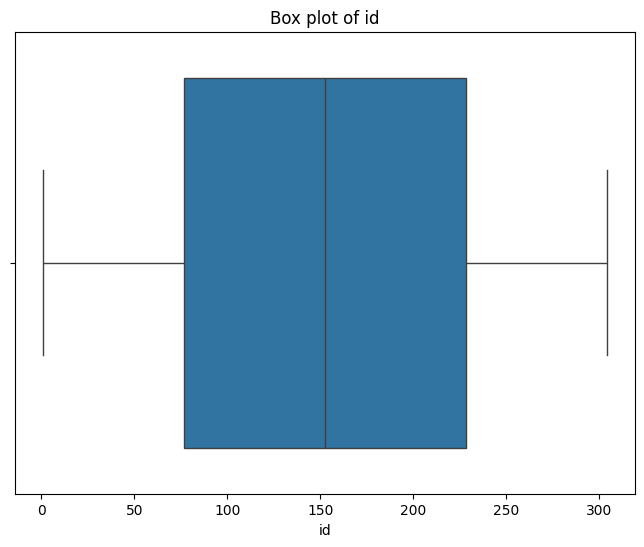

Number of outliers in 'id': 0


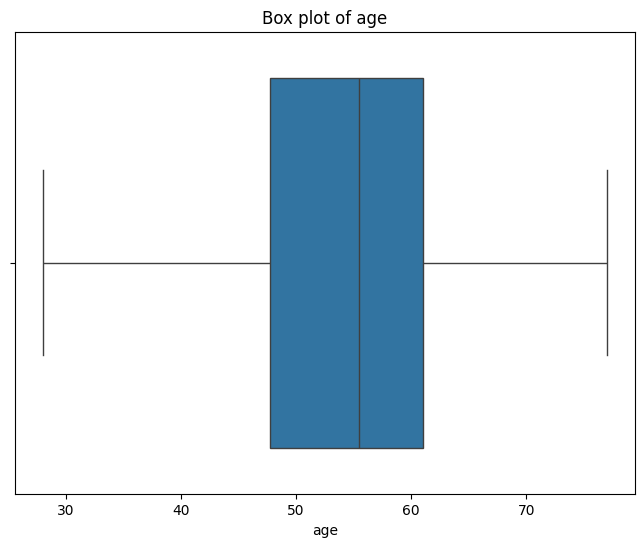

Number of outliers in 'age': 0


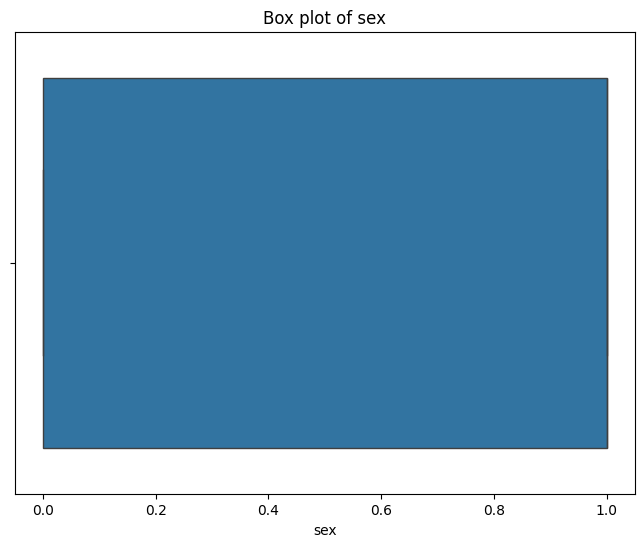

Number of outliers in 'sex': 0


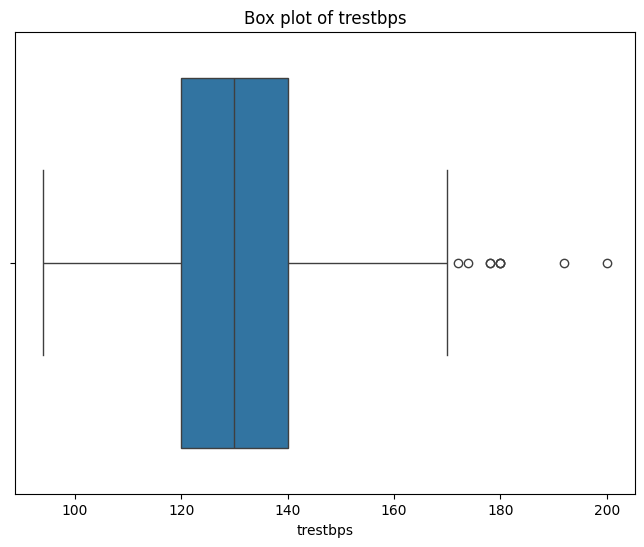

Number of outliers in 'trestbps': 9


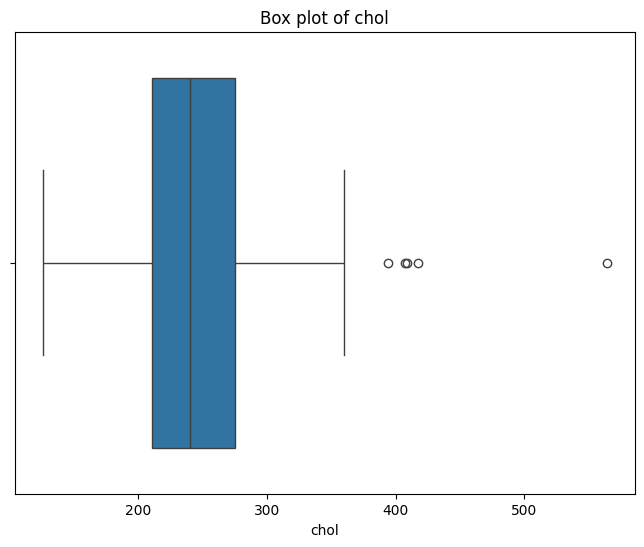

Number of outliers in 'chol': 5


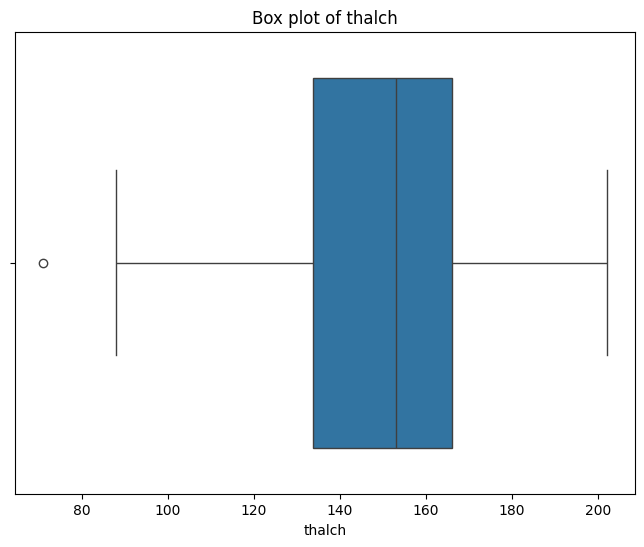

Number of outliers in 'thalch': 1


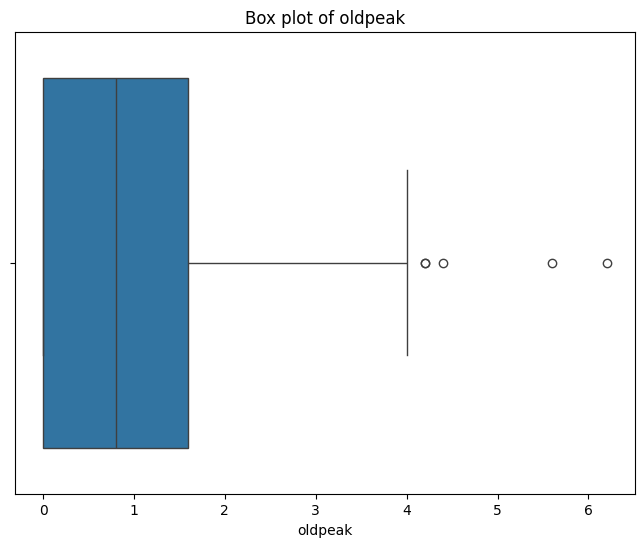

Number of outliers in 'oldpeak': 5


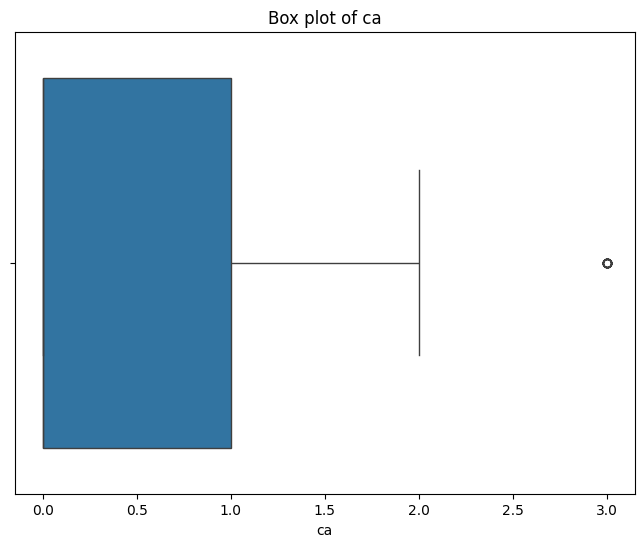

Number of outliers in 'ca': 20


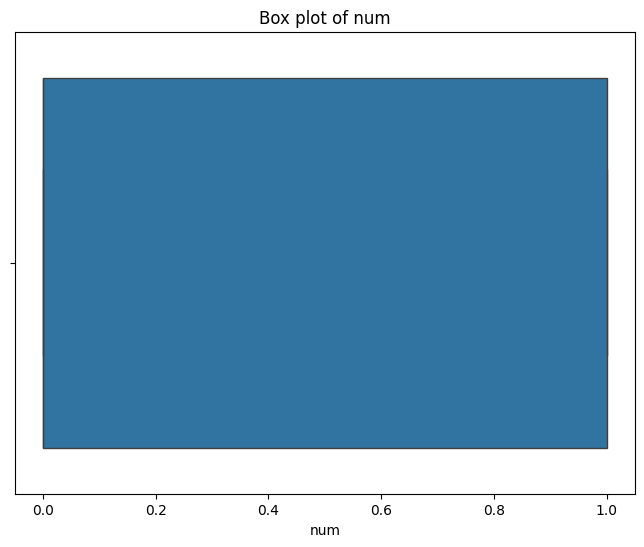

Number of outliers in 'num': 0
Columns to handle outliers: ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

handle_ol = []
# Create box plots and print the number of outliers for each numerical column
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.show()

    # Calculate the number of outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
      handle_ol.append(col)

    print(f"Number of outliers in '{col}': {len(outliers)}")

print(f"Columns to handle outliers: {handle_ol}")

### Log Transformation

In [ ]:
# import numpy as np

# handle_ol_log_transform = [col for col in handle_ol if col not in ['thalch', 'oldpeak', 'ca']]
# for col in handle_ol_log_transform:
#     df[col] = np.log1p(df[col])

# print("Log transformation applied to columns:", handle_ol_log_transform)

### log1p boxplot

In [ ]:
# for col in handle_ol_log_transform:
#     plt.figure(figsize=(8, 6))
#     sns.boxplot(x=df[col])
#     plt.title(f'Box plot of {col}')
#     plt.xlabel(col)
#     plt.show()
#     # distribution
#     sns.histplot(df[col], bins=20)
#     plt.title(f'{col} distribution')
#     plt.tight_layout()
#     plt.show()

#     # Calculate the number of outliers using IQR
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
#     print(f"Number of outliers in '{col}': {len(outliers)}")


## Feature Engeneering

In [ ]:
import pandas as pd

# Define categorical ranges for numerical columns based on common health guidelines
age_bins = [0, 39, 49, 59, float('inf')]
age_labels = ['<40', '40-49', '50-59', '60+']
df['age_category'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

trestbps_bins = [0, 120, 130, 140, float('inf')]
trestbps_labels = ['Normal', 'Elevated', 'Hypertension Stage 1', 'Hypertension Stage 2']
df['trestbps_category'] = pd.cut(df['trestbps'], bins=trestbps_bins, labels=trestbps_labels, right=False)

chol_bins = [0, 125, 200, 240, 280, float('inf')]
chol_labels = ['Very Low', 'Optimal', 'Borderline High', 'High', 'Very High']
df['chol_category'] = pd.cut(df['chol'], bins=chol_bins, labels=chol_labels, right=False)

thalch_bins = [0, 100, 150, float('inf')]
thalch_labels = ['Low', 'Moderate', 'High']
df['thalch_category'] = pd.cut(df['thalch'], bins=thalch_bins, labels=thalch_labels, right=False)

oldpeak_bins = [-float('inf'), 0, 1, 2, float('inf')]
oldpeak_labels = ['<0', '0-1', '1-2', '>2']
df['oldpeak_category'] = pd.cut(df['oldpeak'], bins=oldpeak_bins, labels=oldpeak_labels)

ca_bins = [-float('inf'), 0, 1, 2, 3, float('inf')]
ca_labels = ['0', '1', '2', '3', '4+'] # Based on the unique values observed
df['ca_category'] = pd.cut(df['ca'], bins=ca_bins, labels=ca_labels)

# Display the new categorical columns
display(df[['age_category', 'trestbps_category', 'chol_category', 'thalch_category', 'oldpeak_category', 'ca_category']].head())

,age_category,trestbps_category,chol_category,thalch_category,oldpeak_category,ca_category
0,60+,Hypertension Stage 2,Borderline High,High,>2,0
1,60+,Hypertension Stage 2,Very High,Moderate,1-2,3
2,60+,Elevated,Borderline High,Moderate,>2,2
3,<40,Hypertension Stage 1,High,High,>2,0
4,40-49,Hypertension Stage 1,Borderline High,High,1-2,0


## Feature Selection

In [ ]:
display(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num',
       'age_category', 'trestbps_category', 'chol_category', 'thalch_category',
       'oldpeak_category', 'ca_category'],
      dtype='object')

In [ ]:
df = df.drop(columns=['id'])

In [ ]:
# Identify the original numerical columns that were converted
numerical_cols_to_drop = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Drop the original numerical columns
df = df.drop(columns=numerical_cols_to_drop)

print("Original numerical columns dropped:")
display(df.head())

Original numerical columns dropped:


,sex,dataset,cp,fbs,restecg,exang,slope,thal,num,age_category,trestbps_category,chol_category,thalch_category,oldpeak_category,ca_category
0,1,Cleveland,typical angina,True,lv hypertrophy,False,downsloping,fixed defect,0,60+,Hypertension Stage 2,Borderline High,High,>2,0
1,1,Cleveland,asymptomatic,False,lv hypertrophy,True,flat,normal,1,60+,Hypertension Stage 2,Very High,Moderate,1-2,3
2,1,Cleveland,asymptomatic,False,lv hypertrophy,True,flat,reversable defect,1,60+,Elevated,Borderline High,Moderate,>2,2
3,1,Cleveland,non-anginal,False,normal,False,downsloping,normal,0,<40,Hypertension Stage 1,High,High,>2,0
4,0,Cleveland,atypical angina,False,lv hypertrophy,False,upsloping,normal,0,40-49,Hypertension Stage 1,Borderline High,High,1-2,0


## Corr Matrix

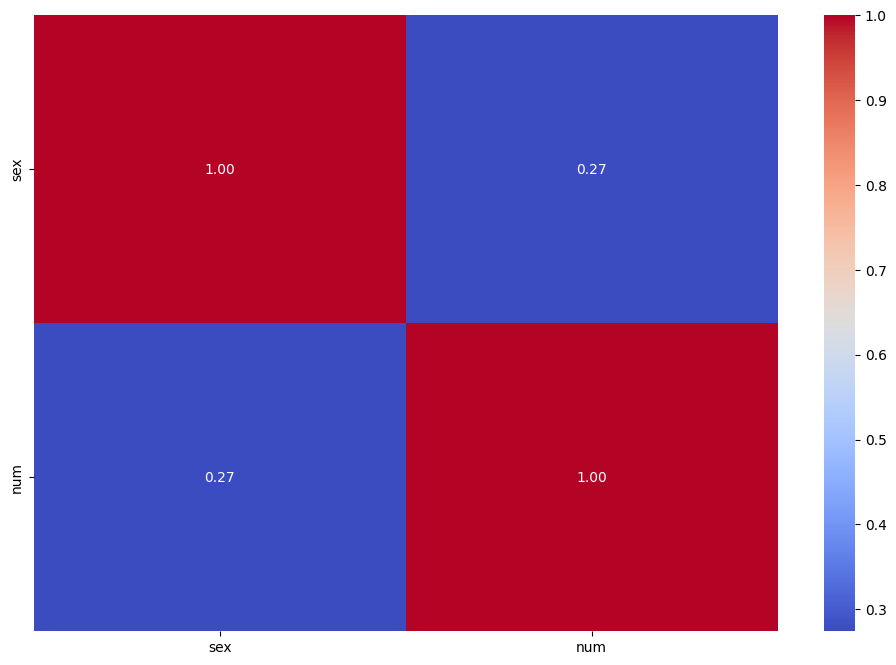

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cor_df = df.select_dtypes(include=[np.number])
corr_matrix = cor_df.corr()

plt.figure(figsize=(12, 8)) # Increase the figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Define feature_sets


In [ ]:
# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['sex', 'num']
Categorical features: ['dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_category', 'trestbps_category', 'chol_category', 'thalch_category', 'oldpeak_category', 'ca_category']


In [ ]:
bool_cols = df.select_dtypes(include='bool').columns
for col in bool_cols:
    df[col] = df[col].astype(int)

In [ ]:
all_features = ['dataset', 'cp', 'fbs', 'restecg', 'exang',
                'slope', 'thal', 'age_category', 'trestbps_category',
                'chol_category', 'thalch_category', 'oldpeak_category',
                'ca_category', 'sex']

feature_sets = [
    # ['sex', 'cp', 'thalch', 'ca', 'oldpeak'],
    # ['trestbps', 'chol', 'sex', 'cp', 'slope'],
    all_features
]


# categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print(feature_sets)

[['dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_category', 'trestbps_category', 'chol_category', 'thalch_category', 'oldpeak_category', 'ca_category', 'sex']]


## Compare models

### logistic regression

**Reasoning**:
Implement and train a Logistic Regression model and evaluate its performance using accuracy, confusion matrix, and classification report as per the instructions.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

evaluation_results = []

# Assuming 'all_features' and 'df' are defined in previous cells
features = all_features

print(f"\nTraining Logistic Regression model with features: {features}")

# Split data
X = df[features]
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Identify numerical features
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features_subset = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Create preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features_subset)
    ],
    remainder='passthrough'
)

# Create and train pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Store results
evaluation_results.append({
    'Model': 'Logistic Regression',
    'Features': features,
    'Accuracy': accuracy,
    'Confusion Matrix': cm,
    'Classification Report': report
})

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(report)


Training Logistic Regression model with features: ['dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_category', 'trestbps_category', 'chol_category', 'thalch_category', 'oldpeak_category', 'ca_category', 'sex']
Accuracy: 0.8478260869565217
Confusion Matrix:
[[42  8]
 [ 6 36]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        50
           1       0.82      0.86      0.84        42

    accuracy                           0.85        92
   macro avg       0.85      0.85      0.85        92
weighted avg       0.85      0.85      0.85        92



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

evaluation_results = []

# Assuming 'all_features' and 'df' are defined in previous cells
features = all_features

print(f"\nTraining Logistic Regression model with features: {features}")

# Split data
X = df[features]
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Identify numerical features
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features_subset = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Create preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features_subset)
    ],
    remainder='passthrough'
)

# Create and train pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Store results
evaluation_results.append({
    'Model': 'Logistic Regression',
    'Features': features,
    'Accuracy': accuracy,
    'Confusion Matrix': cm,
    'Classification Report': report
})

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(report)


Training Logistic Regression model with features: ['dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_category', 'trestbps_category', 'chol_category', 'thalch_category', 'oldpeak_category', 'ca_category', 'sex']
Accuracy: 0.8478260869565217
Confusion Matrix:
[[42  8]
 [ 6 36]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        50
           1       0.82      0.86      0.84        42

    accuracy                           0.85        92
   macro avg       0.85      0.85      0.85        92
weighted avg       0.85      0.85      0.85        92



### decision tree


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

# Define features X and target y
X = df[all_features]
y = df['num']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Identify numerical features
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features_subset = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Create preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features_subset)
    ],
    remainder='passthrough'
)

# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Define parameter grid for GridSearchCV
param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}

# Instantiate and fit GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best estimator
best_dt_model = grid_search.best_estimator_

# Predict on the test set
y_pred_dt = best_dt_model.predict(X_test)

# Evaluate
accuracy_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

# Store results
evaluation_results.append({
    'Model': 'Decision Tree (Tuned)',
    'Features': all_features,
    'Accuracy': accuracy_dt,
    'Confusion Matrix': cm_dt,
    'Classification Report': report_dt
})

print(f"\nBest Decision Tree Model Parameters: {grid_search.best_params_}")
print(f"Accuracy (Decision Tree): {accuracy_dt}")
print("Confusion Matrix (Decision Tree):")
print(cm_dt)
print("Classification Report (Decision Tree):")
print(report_dt)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   


Best Decision Tree Model Parameters: {'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Accuracy (Decision Tree): 0.8043478260869565
Confusion Matrix (Decision Tree):
[[42  8]
 [10 32]]
Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        50
           1       0.80      0.76      0.78        42

    accuracy                           0.80        92
   macro avg       0.80      0.80      0.80        92
weighted avg       0.80      0.80      0.80        92



### random forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

# 1. Split data into training and testing sets
X = df[all_features]
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Create a ColumnTransformer to preprocess the data
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features_subset = X_train.select_dtypes(exclude=np.number).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features_subset)
    ],
    remainder='passthrough'
)

# 3. Create a Pipeline with preprocessor and RandomForestClassifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 4. Define a parameter grid for GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 70, 120, 210],
    'classifier__max_depth': [3, 5, 7, None]
}

# 5. Instantiate and fit GridSearchCV
grid_search_rf = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)

# 6. Get the best estimator
best_rf_model = grid_search_rf.best_estimator_

# 7. Use the best Random Forest model to make predictions on the test set
y_pred_rf = best_rf_model.predict(X_test)

# 8. Evaluate the model's performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

# 9. Store the evaluation results
evaluation_results.append({
    'Model': 'Random Forest (Tuned)',
    'Features': all_features,
    'Accuracy': accuracy_rf,
    'Confusion Matrix': cm_rf,
    'Classification Report': report_rf
})

# 10. Print the results
print(f"\nBest Random Forest Model Parameters: {grid_search_rf.best_params_}")
print(f"Accuracy (Random Forest): {accuracy_rf}")
print("Confusion Matrix (Random Forest):")
print(cm_rf)
print("Classification Report (Random Forest):")
print(report_rf)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   


Best Random Forest Model Parameters: {'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Accuracy (Random Forest): 0.8586956521739131
Confusion Matrix (Random Forest):
[[43  7]
 [ 6 36]]
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        50
           1       0.84      0.86      0.85        42

    accuracy                           0.86        92
   macro avg       0.86      0.86      0.86        92
weighted avg       0.86      0.86      0.86        92



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


**Reasoning**:
Implement and tune a Support Vector Machine model using GridSearchCV, then evaluate the best model and store the results.



In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

# 1. Split data into training and testing sets
X = df[all_features]
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Create a ColumnTransformer to preprocess the data
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_cols)
    ],
    remainder='passthrough'
)

# 3. Create a Pipeline with preprocessor and SVC
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# 4. Define a parameter grid for GridSearchCV
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

# 5. Instantiate and fit GridSearchCV
grid_search_svm = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)

# 6. Get the best estimator
best_svm_model = grid_search_svm.best_estimator_

# 7. Use the best Support Vector Machine model to make predictions on the test set
y_pred_svm = best_svm_model.predict(X_test)

# 8. Evaluate the model's performance
accuracy_svm = accuracy_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

# 9. Store the evaluation results
evaluation_results.append({
    'Model': 'Support Vector Machine (Tuned)',
    'Features': all_features,
    'Accuracy': accuracy_svm,
    'Confusion Matrix': cm_svm,
    'Classification Report': report_svm
})

# 10. Print the results
print(f"\nBest Support Vector Machine Model Parameters: {grid_search_svm.best_params_}")
print(f"Accuracy (Support Vector Machine): {accuracy_svm}")
print("Confusion Matrix (Support Vector Machine):")
print(cm_svm)
print("Classification Report (Support Vector Machine):")
print(report_svm)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   


Best Support Vector Machine Model Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Accuracy (Support Vector Machine): 0.8804347826086957
Confusion Matrix (Support Vector Machine):
[[44  6]
 [ 5 37]]
Classification Report (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        50
           1       0.86      0.88      0.87        42

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


**Reasoning**:
Display the evaluation results for all models in a table format.



In [ ]:
# import pandas as pd

# # Create a list of dictionaries for the comparison table
# comparison_data = []
# for result in evaluation_results:
#     comparison_data.append({
#         'Model': result['Model'],
#         'Accuracy': result['Accuracy'],
#         'Precision (Weighted Avg)': float(result['Classification Report'].splitlines()[-1].split()[0]),
#         'Recall (Weighted Avg)': float(result['Classification Report'].splitlines()[-1].split()[1]),
#         'F1-Score (Weighted Avg)': float(result['Classification Report'].splitlines()[-1].split()[2]),
#     })

# # Create a pandas DataFrame from the comparison data
# comparison_df = pd.DataFrame(comparison_data)

# # Display the comparison table
# print("\nModel Comparison Table:")
# display(comparison_df)

**Reasoning**:
The previous attempt to parse the classification report failed because the last line contains the string 'weighted avg'. Need to parse the classification report correctly to extract the precision, recall, and f1-score for the weighted average.



In [ ]:
import pandas as pd

# Create a list of dictionaries for the comparison table
comparison_data = []
for result in evaluation_results:
    report_lines = result['Classification Report'].splitlines()
    # Find the line containing 'weighted avg'
    weighted_avg_line = None
    for line in report_lines:
        if 'weighted avg' in line:
            weighted_avg_line = line
            break

    if weighted_avg_line:
        # Split the weighted average line by whitespace and extract the values
        parts = weighted_avg_line.split()
        # The precision, recall, and f1-score are typically the 2nd, 3rd, and 4th elements after 'weighted avg'
        # Need to adjust indices based on the actual format
        # Assuming the format is 'weighted avg       precision    recall  f1-score   support'
        # Let's try to find the indices based on the known parts of the line
        try:
            precision_idx = parts.index('weighted') + 2 # Assuming precision is 2 elements after 'weighted'
            recall_idx = parts.index('weighted') + 3 # Assuming recall is 3 elements after 'weighted'
            f1_idx = parts.index('weighted') + 4 # Assuming f1-score is 4 elements after 'weighted'

            precision = float(parts[precision_idx])
            recall = float(parts[recall_idx])
            f1 = float(parts[f1_idx])

            comparison_data.append({
                'Model': result['Model'],
                'Accuracy': result['Accuracy'],
                'Precision (Weighted Avg)': precision,
                'Recall (Weighted Avg)': recall,
                'F1-Score (Weighted Avg)': f1,
            })
        except (ValueError, IndexError) as e:
            print(f"Could not parse classification report for model {result['Model']}: {e}")
            comparison_data.append({
                'Model': result['Model'],
                'Accuracy': result['Accuracy'],
                'Precision (Weighted Avg)': None,
                'Recall (Weighted Avg)': None,
                'F1-Score (Weighted Avg)': None,
            })
    else:
         print(f"Could not find 'weighted avg' in the classification report for model {result['Model']}")
         comparison_data.append({
                'Model': result['Model'],
                'Accuracy': result['Accuracy'],
                'Precision (Weighted Avg)': None,
                'Recall (Weighted Avg)': None,
                'F1-Score (Weighted Avg)': None,
            })


# Create a pandas DataFrame from the comparison data
comparison_df = pd.DataFrame(comparison_data)

# Display the comparison table
print("\nModel Comparison Table:")
display(comparison_df)


Model Comparison Table:


,Model,Accuracy,Precision (Weighted Avg),Recall (Weighted Avg),F1-Score (Weighted Avg)
0,Logistic Regression,0.847826,0.85,0.85,0.85
1,Decision Tree (Tuned),0.804348,0.80,0.80,0.80
2,Random Forest (Tuned),0.858696,0.86,0.86,0.86
3,Support Vector Machine (Tuned),0.880435,0.88,0.88,0.88


### support vector machine (svm)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

# 2. Split the data into training and testing sets
X = df[all_features]
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Identify numerical features in the training data.
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

# 4. Create a ColumnTransformer named preprocessor to preprocess the data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ],
    remainder='passthrough'
)

# 5. Create a Pipeline with preprocessor and SVC
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# 6. Define a parameter grid for GridSearchCV
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

# 7. Instantiate and fit GridSearchCV
grid_search_svm = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)

# 8. Get the best estimator
best_svm_model = grid_search_svm.best_estimator_

# 9. Use the best Support Vector Machine model to make predictions on the test set
y_pred_svm = best_svm_model.predict(X_test)

# 10. Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

# 11. Append results to evaluation_results
evaluation_results.append({
    'Model': 'Support Vector Machine (Tuned)',
    'Features': all_features,
    'Accuracy': accuracy_svm,
    'Confusion Matrix': cm_svm,
    'Classification Report': report_svm
})

# 12. Print the results
print(f"\nBest Support Vector Machine Model Parameters: {grid_search_svm.best_params_}")
print(f"Accuracy (Support Vector Machine): {accuracy_svm}")
print("Confusion Matrix (Support Vector Machine):")
print(cm_svm)
print("Classification Report (Support Vector Machine):")
print(report_svm)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   


Best Support Vector Machine Model Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Accuracy (Support Vector Machine): 0.8804347826086957
Confusion Matrix (Support Vector Machine):
[[44  6]
 [ 5 37]]
Classification Report (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        50
           1       0.86      0.88      0.87        42

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


### Summary

In [ ]:
import pandas as pd

# Create a list of dictionaries for the comparison table
comparison_data = []
for result in evaluation_results:
    report_lines = result['Classification Report'].splitlines()
    # Find the line containing 'weighted avg'
    weighted_avg_line = None
    for line in report_lines:
        if 'weighted avg' in line:
            weighted_avg_line = line
            break

    if weighted_avg_line:
        # Split the weighted average line by whitespace and extract the values
        parts = weighted_avg_line.split()
        # The precision, recall, and f1-score are typically the 2nd, 3rd, and 4th elements after 'weighted avg'
        # Need to adjust indices based on the actual format
        # Assuming the format is 'weighted avg       precision    recall  f1-score   support'
        # Let's try to find the indices based on the known parts of the line
        try:
            precision_idx = parts.index('weighted') + 2 # Assuming precision is 2 elements after 'weighted'
            recall_idx = parts.index('weighted') + 3 # Assuming recall is 3 elements after 'weighted'
            f1_idx = parts.index('weighted') + 4 # Assuming f1-score is 4 elements after 'weighted'

            precision = float(parts[precision_idx])
            recall = float(parts[recall_idx])
            f1 = float(parts[f1_idx])

            comparison_data.append({
                'Model': result['Model'],
                'Accuracy': result['Accuracy'],
                'Precision (Weighted Avg)': precision,
                'Recall (Weighted Avg)': recall,
                'F1-Score (Weighted Avg)': f1,
            })
        except (ValueError, IndexError) as e:
            print(f"Could not parse classification report for model {result['Model']}: {e}")
            comparison_data.append({
                'Model': result['Model'],
                'Accuracy': result['Accuracy'],
                'Precision (Weighted Avg)': None,
                'Recall (Weighted Avg)': None,
                'F1-Score (Weighted Avg)': None,
            })
    else:
         print(f"Could not find 'weighted avg' in the classification report for model {result['Model']}")
         comparison_data.append({
                'Model': result['Model'],
                'Accuracy': result['Accuracy'],
                'Precision (Weighted Avg)': None,
                'Recall (Weighted Avg)': None,
                'F1-Score (Weighted Avg)': None,
            })


# Create a pandas DataFrame from the comparison data
comparison_df = pd.DataFrame(comparison_data)

# Display the comparison table
print("\nModel Comparison Table:")
display(comparison_df)


Model Comparison Table:


,Model,Accuracy,Precision (Weighted Avg),Recall (Weighted Avg),F1-Score (Weighted Avg)
0,Logistic Regression,0.847826,0.85,0.85,0.85
1,Decision Tree (Tuned),0.804348,0.80,0.80,0.80
2,Random Forest (Tuned),0.858696,0.86,0.86,0.86
3,Support Vector Machine (Tuned),0.880435,0.88,0.88,0.88
4,Support Vector Machine (Tuned),0.880435,0.88,0.88,0.88
